# 02 — Exploratory Data Analysis (EDA)

## Projet : Online Shoppers Conversion Analysis

### Problématique

**Quels comportements de navigation et quelles caractéristiques de session sont associés à un achat, et comment l'entreprise peut-elle améliorer son taux de conversion ?**

Ce notebook analyse :

- le taux de conversion global ;
- le comportement des visiteurs qui achètent ;
- le type de visiteur ;
- les mois et les week-ends ;
- les sources de trafic anonymisées ;
- le nombre de pages produits consultées ;
- les taux de rebond et de sortie.

Le code est volontairement simple et facile à comprendre.

## À propos du dataset

Le dataset contient une ligne par session de visite.

La colonne `revenue` indique si la session s'est terminée par un achat :

- `0` : aucun achat ;
- `1` : achat.

Les colonnes `traffictype`, `browser`, `region` et `operatingsystems` sont des codes anonymisés. Nous pouvons comparer leurs performances, mais pas leur donner un nom réel.

Source : UCI Machine Learning Repository — Online Shoppers Purchasing Intention Dataset.

## 1. Importer les bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. Charger les données nettoyées

In [2]:
from pathlib import Path

# The notebook can be run from the repository root or from the notebooks folder.
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

file_path = project_root / "data" / "processed" / "online_shoppers_cleaned.csv"

df = pd.read_csv(file_path)

df.head()

,administrative,administrative_duration,informational,informational_duration,productrelated,productrelated_duration,bouncerates,exitrates,pagevalues,specialday,month,operatingsystems,browser,region,traffictype,visitortype,weekend,revenue,month_number
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning Visitor,0,0,2
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning Visitor,0,0,2
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning Visitor,0,0,2
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning Visitor,0,0,2
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning Visitor,1,0,2


## 3. Vérification rapide

In [3]:
print("Nombre de sessions :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])
print("Valeurs manquantes :", df.isnull().sum().sum())

Nombre de sessions : 12330
Nombre de colonnes : 19
Valeurs manquantes : 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   administrative           12330 non-null  int64  
 1   administrative_duration  12330 non-null  float64
 2   informational            12330 non-null  int64  
 3   informational_duration   12330 non-null  float64
 4   productrelated           12330 non-null  int64  
 5   productrelated_duration  12330 non-null  float64
 6   bouncerates              12330 non-null  float64
 7   exitrates                12330 non-null  float64
 8   pagevalues               12330 non-null  float64
 9   specialday               12330 non-null  float64
 10  month                    12330 non-null  object 
 11  operatingsystems         12330 non-null  int64  
 12  browser                  12330 non-null  int64  
 13  region                   12330 non-null  int64  
 14  traffictype           

## 4. KPI principaux

In [5]:
total_sessions = len(df)
total_purchases = df["revenue"].sum()
conversion_rate = df["revenue"].mean() * 100

print("Nombre total de sessions :", total_sessions)
print("Nombre de sessions avec achat :", total_purchases)
print("Taux de conversion global :", round(conversion_rate, 2), "%")

Nombre total de sessions : 12330
Nombre de sessions avec achat : 1908
Taux de conversion global : 15.47 %


### Répartition des sessions avec et sans achat

In [6]:
purchase_distribution = df["revenue"].value_counts().sort_index()

purchase_distribution.index = ["Pas d'achat", "Achat"]

purchase_distribution

Pas d'achat    10422
Achat           1908
Name: count, dtype: int64

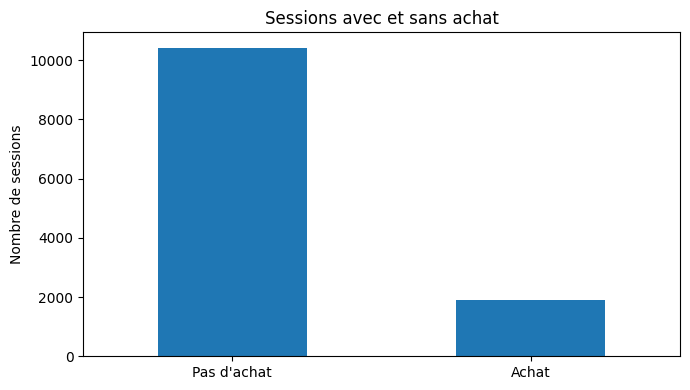

In [7]:
purchase_distribution.plot(kind="bar", figsize=(7, 4))

plt.title("Sessions avec et sans achat")
plt.xlabel("")
plt.ylabel("Nombre de sessions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Premier constat

Le taux de conversion global est d'environ **15,47 %**.

La majorité des sessions ne se termine donc pas par un achat. L'objectif principal est de comprendre ce qui différencie les sessions converties des autres.

## 5. Comportement des visiteurs avec et sans achat

In [8]:
behavior_columns = [
    "administrative",
    "informational",
    "productrelated",
    "administrative_duration",
    "informational_duration",
    "productrelated_duration",
    "bouncerates",
    "exitrates",
    "pagevalues"
]

behavior_comparison = df.groupby("revenue")[behavior_columns].mean().round(2)

behavior_comparison.index = ["Pas d'achat", "Achat"]

behavior_comparison

,administrative,informational,productrelated,administrative_duration,informational_duration,productrelated_duration,bouncerates,exitrates,pagevalues
Pas d'achat,2.12,0.45,28.71,73.74,30.24,1069.99,0.03,0.05,1.98
Achat,3.39,0.79,48.21,119.48,57.61,1876.21,0.01,0.02,27.26


### Nombre moyen de pages visitées

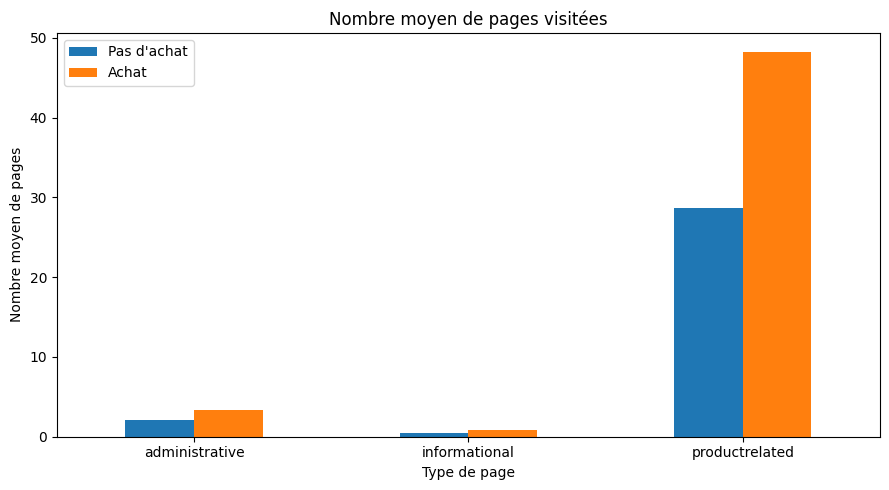

In [9]:
pages_comparison = df.groupby("revenue")[
    ["administrative", "informational", "productrelated"]
].mean().T

pages_comparison.columns = ["Pas d'achat", "Achat"]

pages_comparison.plot(kind="bar", figsize=(9, 5))

plt.title("Nombre moyen de pages visitées")
plt.xlabel("Type de page")
plt.ylabel("Nombre moyen de pages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Temps moyen passé sur les pages produits

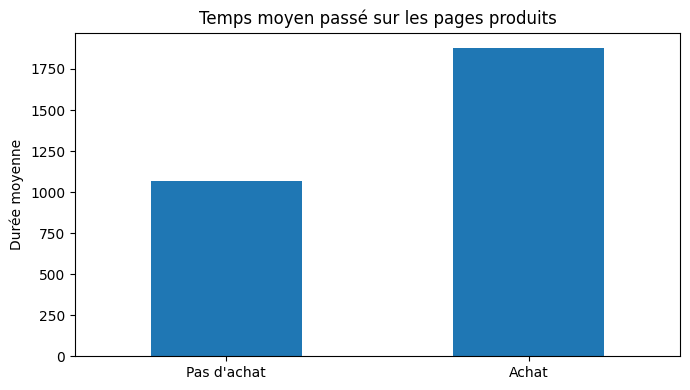

In [10]:
product_duration = df.groupby("revenue")["productrelated_duration"].mean()

product_duration.index = ["Pas d'achat", "Achat"]

product_duration.plot(kind="bar", figsize=(7, 4))

plt.title("Temps moyen passé sur les pages produits")
plt.xlabel("")
plt.ylabel("Durée moyenne")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Taux de rebond et taux de sortie moyens

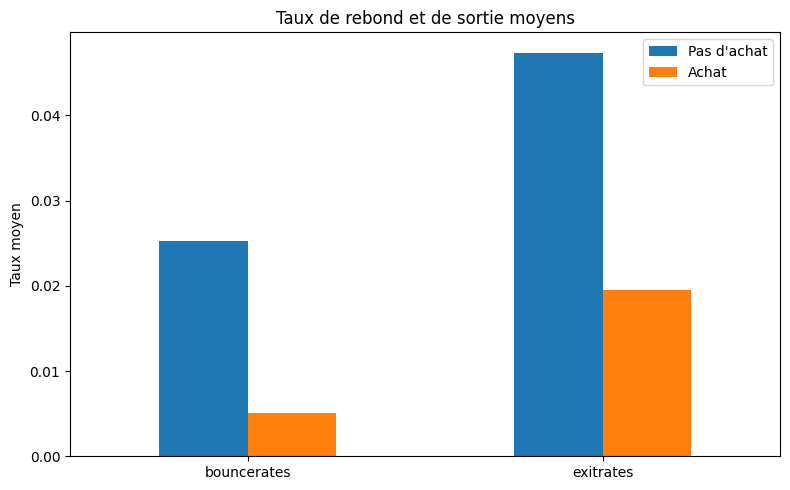

In [11]:
bounce_exit = df.groupby("revenue")[["bouncerates", "exitrates"]].mean().T

bounce_exit.columns = ["Pas d'achat", "Achat"]

bounce_exit.plot(kind="bar", figsize=(8, 5))

plt.title("Taux de rebond et de sortie moyens")
plt.xlabel("")
plt.ylabel("Taux moyen")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Résultat

Les sessions qui aboutissent à un achat :

- consultent en moyenne **48,21 pages produits**, contre **28,71** sans achat ;
- passent environ **1 876** unités de temps sur les pages produits, contre **1 070** ;
- ont un taux de rebond moyen d'environ **0,51 %**, contre **2,53 %** ;
- ont un taux de sortie moyen d'environ **1,96 %**, contre **4,74 %**.

Cela montre une forte association entre l'engagement sur les pages produits et la conversion.

## 6. Le nombre de pages produits et la conversion

In [12]:
df["product_pages_group"] = pd.cut(
    df["productrelated"],
    bins=[-1, 0, 10, 30, 60, float("inf")],
    labels=["0", "1-10", "11-30", "31-60", "61+"]
)

conversion_by_product_pages = df.groupby(
    "product_pages_group",
    observed=False
)["revenue"].agg(["count", "sum", "mean"])

conversion_by_product_pages.columns = [
    "sessions",
    "achats",
    "taux_conversion"
]

conversion_by_product_pages["taux_conversion"] = (
    conversion_by_product_pages["taux_conversion"] * 100
).round(2)

conversion_by_product_pages

,sessions,achats,taux_conversion
product_pages_group,,,
0,38,6,15.79
1-10,4135,281,6.80
11-30,4251,727,17.10
31-60,2229,454,20.37
61+,1677,440,26.24


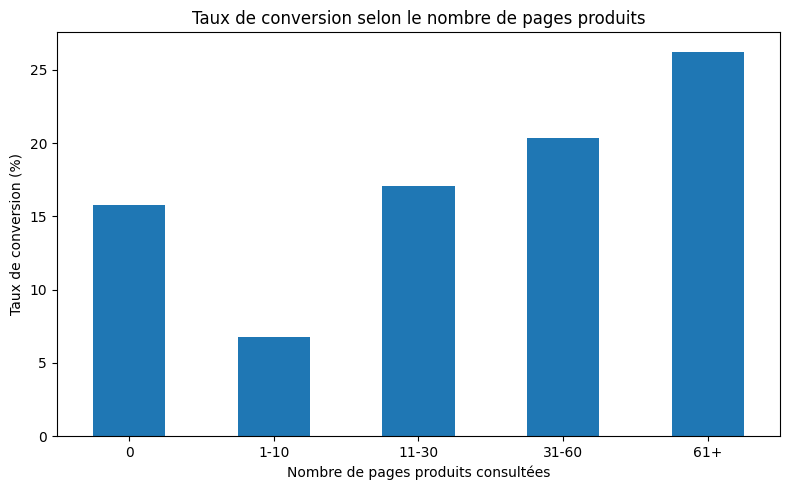

In [13]:
conversion_by_product_pages["taux_conversion"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Taux de conversion selon le nombre de pages produits")
plt.xlabel("Nombre de pages produits consultées")
plt.ylabel("Taux de conversion (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Résultat

Le taux de conversion augmente globalement avec le nombre de pages produits consultées :

- **1 à 10 pages : 6,80 %** ;
- **11 à 30 pages : 17,10 %** ;
- **31 à 60 pages : 20,37 %** ;
- **61 pages ou plus : 26,24 %**.

Cette relation ne prouve pas que montrer davantage de pages provoque l'achat. Elle indique surtout que les visiteurs les plus engagés convertissent davantage.

## 7. Le taux de sortie et la conversion

In [14]:
df["exit_rate_group"] = pd.cut(
    df["exitrates"],
    bins=[-0.001, 0.02, 0.04, 0.06, 0.10, float("inf")],
    labels=["2 % ou moins", "2-4 %", "4-6 %", "6-10 %", "Plus de 10 %"]
)

conversion_by_exit_rate = df.groupby(
    "exit_rate_group",
    observed=False
)["revenue"].agg(["count", "sum", "mean"])

conversion_by_exit_rate.columns = [
    "sessions",
    "achats",
    "taux_conversion"
]

conversion_by_exit_rate["taux_conversion"] = (
    conversion_by_exit_rate["taux_conversion"] * 100
).round(2)

conversion_by_exit_rate

,sessions,achats,taux_conversion
exit_rate_group,,,
2 % ou moins,4842,1201,24.80
2-4 %,3709,571,15.39
4-6 %,1397,86,6.16
6-10 %,1270,44,3.46
Plus de 10 %,1112,6,0.54


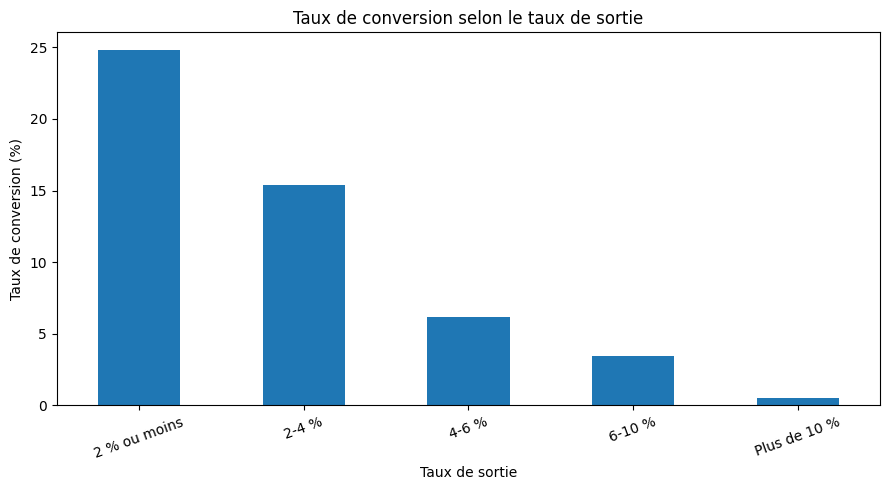

In [15]:
conversion_by_exit_rate["taux_conversion"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Taux de conversion selon le taux de sortie")
plt.xlabel("Taux de sortie")
plt.ylabel("Taux de conversion (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Résultat

La conversion diminue fortement lorsque le taux de sortie augmente :

- taux de sortie inférieur ou égal à 2 % : **24,80 %** de conversion ;
- entre 4 % et 6 % : **6,16 %** ;
- plus de 10 % : seulement **0,54 %**.

La réduction des sorties prématurées est donc un axe important d'amélioration.

## 8. Conversion par type de visiteur

In [16]:
visitor_analysis = df.groupby("visitortype")["revenue"].agg(
    ["count", "sum", "mean"]
)

visitor_analysis.columns = ["sessions", "achats", "taux_conversion"]
visitor_analysis["taux_conversion"] = (
    visitor_analysis["taux_conversion"] * 100
).round(2)

visitor_analysis = visitor_analysis.sort_values(
    "taux_conversion",
    ascending=False
)

visitor_analysis

,sessions,achats,taux_conversion
visitortype,,,
New Visitor,1694,422,24.91
Other,85,16,18.82
Returning Visitor,10551,1470,13.93


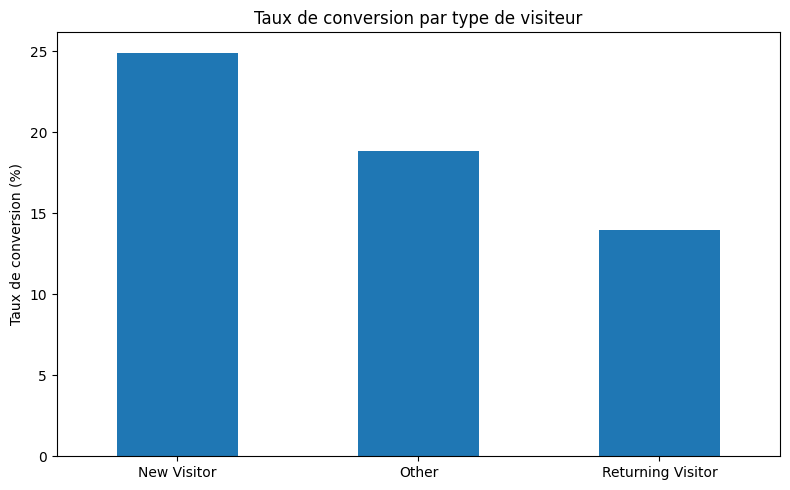

In [17]:
visitor_analysis["taux_conversion"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Taux de conversion par type de visiteur")
plt.xlabel("")
plt.ylabel("Taux de conversion (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Résultat

- nouveaux visiteurs : **24,91 %** ;
- autres visiteurs : **18,82 %** ;
- visiteurs récurrents : **13,93 %**.

Les visiteurs récurrents représentent la majorité du trafic, mais leur taux de conversion est plus faible. Il faudrait analyser leur parcours plus en détail et prévoir des actions de remarketing ou de personnalisation.

## 9. Conversion par mois

In [18]:
monthly_analysis = df.groupby(
    ["month_number", "month"]
)["revenue"].agg(["count", "sum", "mean"]).reset_index()

monthly_analysis.columns = [
    "month_number",
    "month",
    "sessions",
    "achats",
    "taux_conversion"
]

monthly_analysis["taux_conversion"] = (
    monthly_analysis["taux_conversion"] * 100
).round(2)

monthly_analysis = monthly_analysis.sort_values("month_number")

monthly_analysis

,month_number,month,sessions,achats,taux_conversion
0,2,Feb,184,3,1.63
1,3,Mar,1907,192,10.07
2,5,May,3364,365,10.85
3,6,Jun,288,29,10.07
4,7,Jul,432,66,15.28
5,8,Aug,433,76,17.55
6,9,Sep,448,86,19.20
7,10,Oct,549,115,20.95
8,11,Nov,2998,760,25.35
9,12,Dec,1727,216,12.51


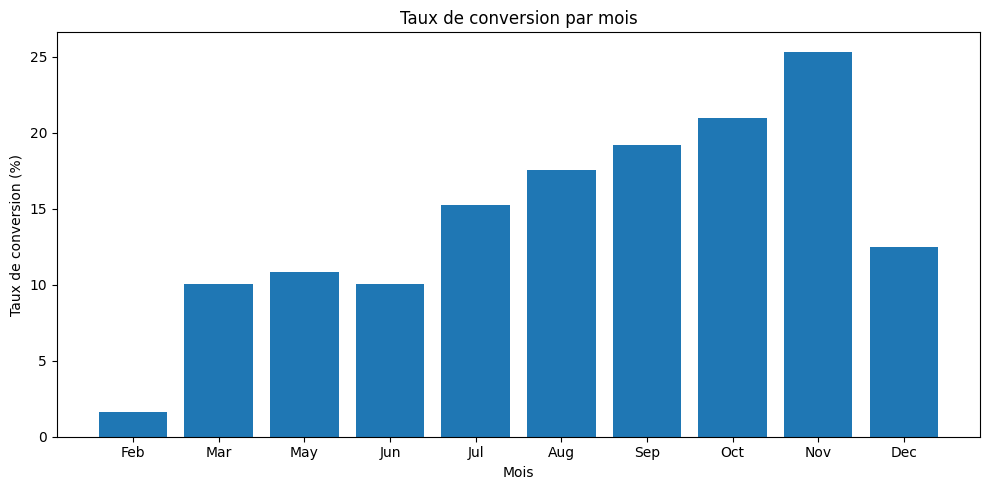

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(
    monthly_analysis["month"],
    monthly_analysis["taux_conversion"]
)

plt.title("Taux de conversion par mois")
plt.xlabel("Mois")
plt.ylabel("Taux de conversion (%)")
plt.tight_layout()
plt.show()

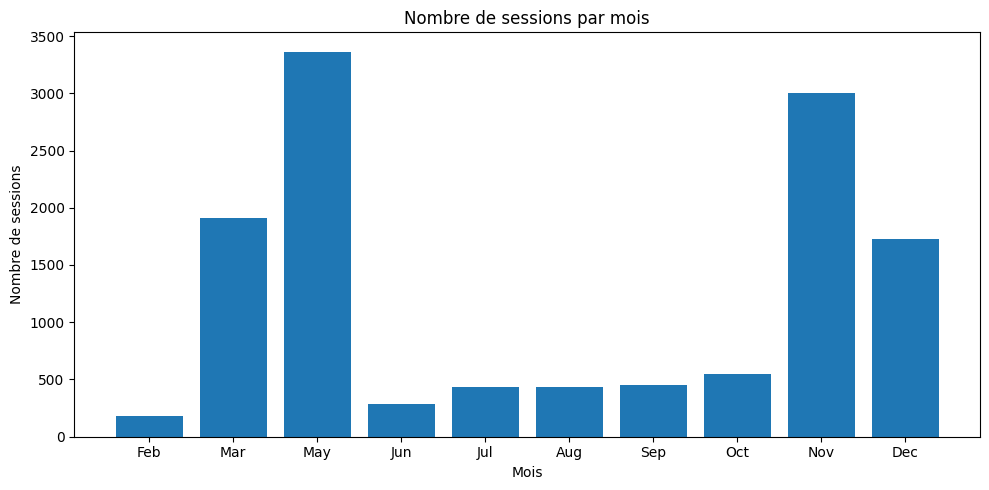

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(
    monthly_analysis["month"],
    monthly_analysis["sessions"]
)

plt.title("Nombre de sessions par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de sessions")
plt.tight_layout()
plt.show()

### Résultat

Les meilleurs taux de conversion apparaissent en :

- **novembre : 25,35 %** ;
- **octobre : 20,95 %** ;
- **septembre : 19,20 %**.

Février présente seulement **1,63 %**, mais avec un volume de sessions beaucoup plus faible. Les différences doivent donc être interprétées avec prudence.

Novembre combine un volume élevé et le meilleur taux de conversion. C'est une période importante pour les campagnes commerciales.

## 10. Semaine ou week-end

In [21]:
weekend_analysis = df.groupby("weekend")["revenue"].agg(
    ["count", "sum", "mean"]
)

weekend_analysis.columns = ["sessions", "achats", "taux_conversion"]
weekend_analysis.index = ["Semaine", "Week-end"]
weekend_analysis["taux_conversion"] = (
    weekend_analysis["taux_conversion"] * 100
).round(2)

weekend_analysis

,sessions,achats,taux_conversion
Semaine,9462,1409,14.89
Week-end,2868,499,17.40


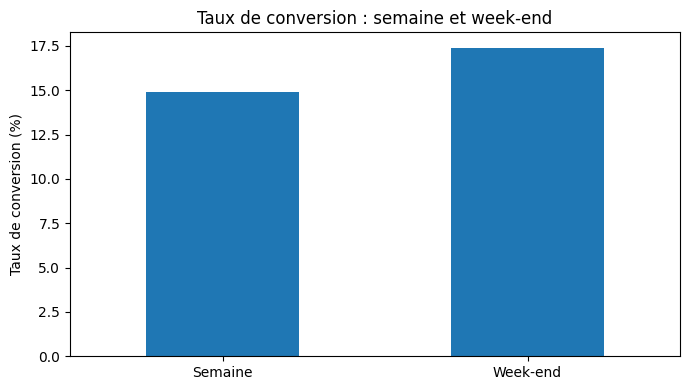

In [22]:
weekend_analysis["taux_conversion"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Taux de conversion : semaine et week-end")
plt.xlabel("")
plt.ylabel("Taux de conversion (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Résultat

Le taux de conversion est légèrement supérieur le week-end :

- semaine : **14,89 %** ;
- week-end : **17,40 %**.

L'entreprise peut tester des campagnes ou promotions spécifiques au week-end.

## 11. Performance des types de trafic

In [23]:
traffic_analysis = df.groupby("traffictype")["revenue"].agg(
    ["count", "sum", "mean"]
).reset_index()

traffic_analysis.columns = [
    "traffictype",
    "sessions",
    "achats",
    "taux_conversion"
]

traffic_analysis["taux_conversion"] = (
    traffic_analysis["taux_conversion"] * 100
).round(2)

traffic_analysis = traffic_analysis.sort_values(
    "sessions",
    ascending=False
)

traffic_analysis

,traffictype,sessions,achats,taux_conversion
1,2,3913,847,21.65
0,1,2451,262,10.69
2,3,2052,180,8.77
3,4,1069,165,15.43
12,13,738,43,5.83
9,10,450,90,20.00
5,6,444,53,11.94
7,8,343,95,27.70
4,5,260,56,21.54
10,11,247,47,19.03


Pour éviter de mettre en avant un type de trafic basé sur trop peu de sessions, nous conservons uniquement les types ayant au moins 100 sessions.

In [24]:
main_traffic_types = traffic_analysis[
    traffic_analysis["sessions"] >= 100
].copy()

main_traffic_types = main_traffic_types.sort_values(
    "taux_conversion",
    ascending=False
)

main_traffic_types

,traffictype,sessions,achats,taux_conversion
7,8,343,95,27.70
19,20,198,50,25.25
1,2,3913,847,21.65
4,5,260,56,21.54
9,10,450,90,20.00
10,11,247,47,19.03
3,4,1069,165,15.43
5,6,444,53,11.94
0,1,2451,262,10.69
2,3,2052,180,8.77


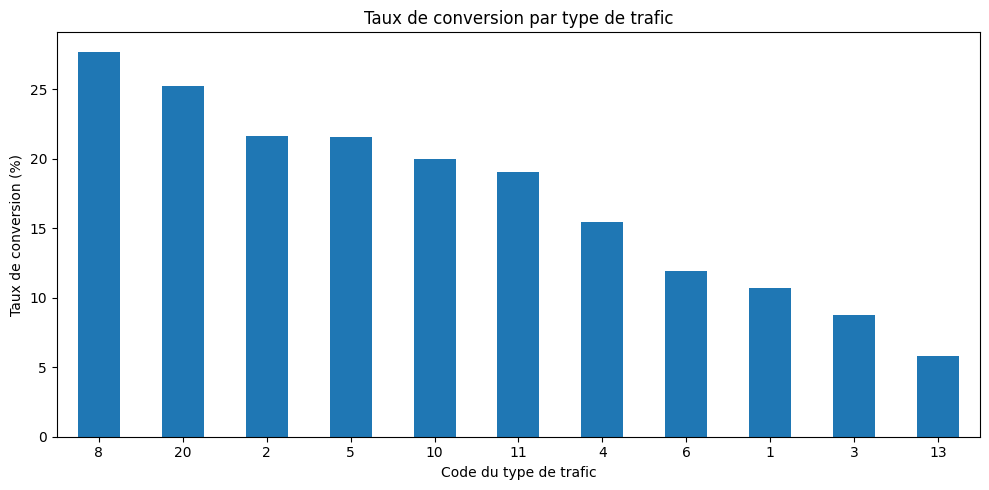

In [25]:
main_traffic_types.plot(
    x="traffictype",
    y="taux_conversion",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Taux de conversion par type de trafic")
plt.xlabel("Code du type de trafic")
plt.ylabel("Taux de conversion (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Résultat

Parmi les types de trafic ayant au moins 100 sessions :

- le type **8** atteint environ **27,70 %** ;
- le type **20** atteint environ **25,25 %** ;
- le type **2** atteint environ **21,65 %** et apporte aussi un volume important ;
- le type **13** est beaucoup plus faible, avec environ **5,83 %**.

Avant de prendre une décision marketing, l'entreprise doit relier ces codes anonymisés aux vrais canaux d'acquisition.

## 12. Variables les plus associées à l'achat

In [26]:
numeric_columns = df.select_dtypes(include="number").columns

correlation_with_purchase = (
    df[numeric_columns]
    .corr()["revenue"]
    .drop("revenue")
    .sort_values(ascending=False)
)

correlation_with_purchase

pagevalues                 0.492569
productrelated             0.158538
productrelated_duration    0.152373
administrative             0.138917
month_number               0.127372
informational              0.095200
administrative_duration    0.093587
informational_duration     0.070345
weekend                    0.029295
browser                    0.023984
traffictype               -0.005113
region                    -0.011595
operatingsystems          -0.014668
specialday                -0.082305
bouncerates               -0.150673
exitrates                 -0.207071
Name: revenue, dtype: float64

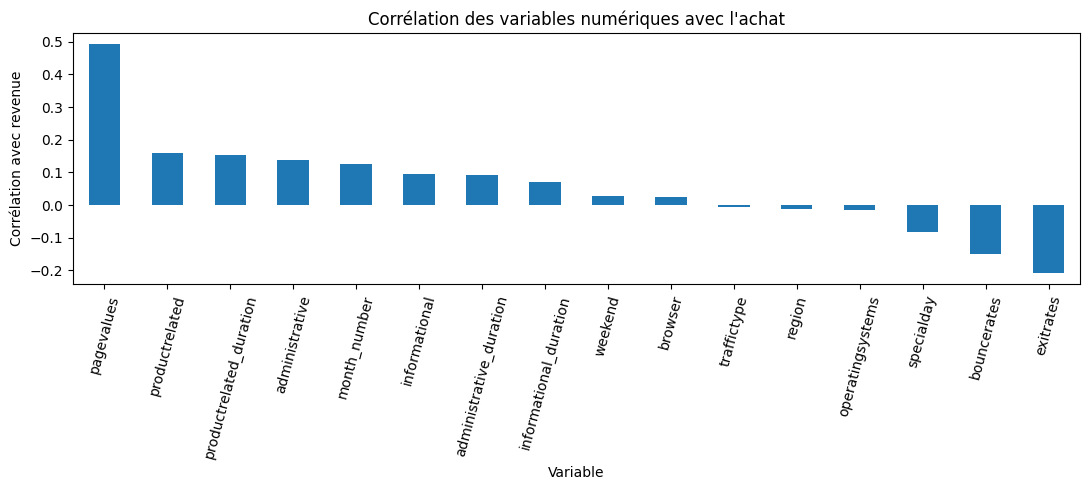

In [27]:
correlation_with_purchase.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Corrélation des variables numériques avec l'achat")
plt.xlabel("Variable")
plt.ylabel("Corrélation avec revenue")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### Attention à `pagevalues`

`pagevalues` est très fortement associé à l'achat. Cependant, cette mesure représente la valeur moyenne des pages visitées avant une transaction.

Elle est utile pour décrire les sessions, mais elle ne doit pas être présentée comme une action business directe. Elle pourrait également créer une fuite d'information dans un futur modèle prédictif si elle utilise des informations liées à la transaction.

# 13. Réponse à la problématique

## Quels comportements sont associés à l'achat ?

Les visiteurs qui achètent :

1. consultent davantage de pages produits ;
2. passent plus de temps sur les pages produits ;
3. quittent moins rapidement le site ;
4. ont des taux de rebond et de sortie plus faibles ;
5. convertissent davantage durant les mois de septembre à novembre ;
6. convertissent légèrement mieux le week-end ;
7. proviennent de certains types de trafic nettement plus performants.

## Recommandations business

### 1. Réduire les sorties prématurées

Améliorer les pages qui présentent les taux de sortie les plus élevés :

- meilleure vitesse de chargement ;
- navigation plus claire ;
- informations produit plus complètes ;
- boutons d'action visibles ;
- processus de paiement plus simple.

### 2. Encourager l'exploration des produits

Mettre en place :

- recommandations de produits ;
- produits similaires ;
- filtres de recherche plus simples ;
- comparateur de produits ;
- liens vers les catégories associées.

### 3. Travailler les visiteurs récurrents

Ils représentent la majorité des sessions, mais convertissent moins bien que les nouveaux visiteurs.

Actions possibles :

- relances personnalisées ;
- paniers sauvegardés ;
- recommandations basées sur les visites précédentes ;
- offres de retour ciblées.

### 4. Profiter des périodes fortes

Renforcer les campagnes de septembre à novembre, surtout en novembre, tout en préparant suffisamment les stocks et les équipes.

### 5. Réallouer le budget marketing

Identifier les vrais canaux correspondant aux types de trafic 8, 20 et 2, puis comparer leur coût d'acquisition avant d'augmenter les investissements.

## Conclusion générale

La conversion dépend principalement de l'engagement du visiteur et de sa capacité à poursuivre sa navigation sans quitter le site.

La priorité n'est donc pas seulement d'attirer davantage de trafic. Il faut surtout :

**attirer un trafic qualifié, améliorer les pages produits et réduire les sorties avant l'achat.**

# 14. Limites de l'analyse

Le dataset ne contient pas :

- d'identifiant client ;
- de montant de commande ;
- de détail sur les produits ;
- de noms réels pour les canaux de trafic ;
- de parcours complet entre plusieurs sessions ;
- de coût marketing.

Il n'est donc pas possible de calculer correctement :

- la rétention client ;
- la valeur vie client ;
- le panier moyen ;
- le retour sur investissement marketing ;
- le funnel complet page par page.

Les résultats montrent des associations et non des relations de cause à effet.